# **Question 1: Feedforward Neural Networks using Tabular Data**

In this question, you will work with a real-world tabular dataset derived from Airbnb listings
in New York City. Each row corresponds to one Airbnb listing, with the following columns:
- **neighbourhood group:** NYC borough (categorical)
- **room type:** Type of accommodation (categorical)
- **minimum nights:** Minimum nights required for booking (numeric)
- **number of reviews:** Total number of reviews (numeric)
- **availability 365:** Number of available days in the next year (numeric)
- **amenity score:** Listing amenity/quality score (numeric)
- **price class:** Price category label in {0 = Budget, 1 = M oderate, 2 = P remium, 3 =
Luxury} listings


The purpose of this question is not only to train a feedforward neural network, but also to develop a principle understanding of how data characteristics influence model behavior and generalization. You are provided with two files: train.csv and test.csv. The training file should be used for model development and validation, while the test file must be treated as a held-out dataset and used only for final evaluation. The target variable is price class.

## Part A: Data Preprocessing and Exploratory Analysis

Before training any model, you must perform a thorough exploratory data analysis (EDA) on the provided training dataset. Your submission must explicitly include the following:
- Describe the dataset structure, including the number of samples, number of features and
data types.
- Identify missing values (if any) for each feature and clearly state the strategy used to handle missing data and justify why your choice is a better approach in current scenario.
- Analyze and report the class distribution of the target variable. Include a visualization (e.g., bar chart) and comment on any imbalance.
- Encode categorical variables using an appropriate encoding scheme. Justify your choice.
- Normalize your numerical features and clearly state the method used for normalization, and why?
- Plot and analyze relationships between individual features and the target variable using suitable visualizations.
- Visualize the correlation matrix among numerical features. Identify and discuss highly correlated feature pairs.
- Based on the above analysis, explicitly state:
        - Which features you expect to be most influential for prediction.
        - Whether any feature appears unusually predictive or suspiciously dominant.
All claims must be supported by visual or quantitative evidence.

In [270]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [271]:
df = pd.read_csv("train.csv")

In [272]:
df.head()

,neighbourhood_group,room_type,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class
0,Manhattan,NaN,2.0,82.5,15.0,254.0,3
1,Manhattan,Private room,2.0,53.7,1.0,0.0,1
2,Brooklyn,Private room,2.0,47.8,70.0,90.0,1
3,Manhattan,Entire home/apt,2.0,58.8,1.0,NaN,1
4,Bronx,Private room,2.0,32.2,0.0,89.0,1


In [273]:
TARGET = df.columns[-1]

### 1. Dataset Structure

In [274]:
print("\n===== DATASET STRUCTURE =====")
print("Shape (rows, cols):", df.shape)
print("\nData types:\n",df.dtypes)
n_samples = df.shape[0]
n_features = df.shape[1] - 1
print(f"\n No of Samples: {n_samples}")
print(f" No of Features (Columns) | excluding target: {n_features}")


===== DATASET STRUCTURE =====
Shape (rows, cols): (41348, 7)

Data types:
 neighbourhood_group        str
room_type                  str
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object

 No of Samples: 41348
 No of Features (Columns) | excluding target: 6


### 2. Handling Missing Values

In [275]:
print("\n===== Missing Values =====")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)


===== Missing Values =====
minimum_nights         1322
number_of_reviews      1123
amenity_score           916
neighbourhood_group     839
room_type               611
availability_365        595
price_class               0
dtype: int64


In [276]:
# a. minimum_nights
print(f"Skewness {df['minimum_nights'].skew().round(2)}")
print(f"\ncol description\n{df['minimum_nights'].describe()}")
print(f"\nMissing {df['minimum_nights'].isna().sum()}")

Skewness 20.91

col description
count    40026.000000
mean         7.002873
std         19.725353
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1000.000000
Name: minimum_nights, dtype: float64

Missing 1322


In [277]:
# checking the respective median values across different neighborhood and room type
print(f"Median across neighborhood_group {df.groupby('neighbourhood_group')['minimum_nights'].median()}")
print(f"\nMedian across room_type {df.groupby('room_type')['minimum_nights'].median()}")

Median across neighborhood_group neighbourhood_group
Bronx            2.0
Brooklyn         3.0
Manhattan        3.0
Queens           2.0
Staten Island    2.0
Name: minimum_nights, dtype: float64

Median across room_type room_type
Entire home/apt    3.0
Private room       2.0
Shared room        1.0
Name: minimum_nights, dtype: float64


#### Imputation strategy for `minimum_nights`
The dataset contains missing values across multiple features, with the highest proportion observed in minimum_nights (1,322 missing values, approximately 3% of the dataset). Since the proportion of missing values is relatively small, row deletion was not considered appropriate, as it would unnecessarily reduce the dataset size and potentially discard useful information.

The feature minimum_nights exhibits extreme positive skewness (`skewness coefficient = 20.9`). Descriptive statistics show:

- Median = 3

- 75th percentile = 5

- Maximum = 1000

The large discrepancy between the median (3) and maximum (1000), along with the substantial skewness value, indicates the presence of strong right-tail outliers. Therefore, mean imputation would be inappropriate, as it would be heavily influenced by extreme values.

Group-wise median imputation was evaluated by computing the median `minimum_nights` within each `neighbourhood_group` and `room_type`. The results showed only minor variation across groups (medians ranging from 1 to 3 nights). Since these differences were small and unlikely to significantly impact model performance, **global median imputation** was selected for simplicity and robustness.

In [278]:
# using MEDIAN to fill in the missing values in 'minimum_nights'
df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())

In [279]:
# b. number_of_reviews
print(df["number_of_reviews"].describe())
print("Skewness:", df["number_of_reviews"].skew())
print(f"Missing {df['number_of_reviews'].isna().sum()}")


count    40225.000000
mean        23.648154
std         44.518303
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        607.000000
Name: number_of_reviews, dtype: float64
Skewness: 3.6115051454925142
Missing 1123


In [280]:
review_missing = df["number_of_reviews"].isna().map({
    False: "Reviews Present",
    True: "Reviews Missing"
})

print(df.groupby(review_missing)["availability_365"].mean())

number_of_reviews
Reviews Missing    102.129730
Reviews Present    112.186086
Name: availability_365, dtype: float64


#### Imputation strategy for `number_of_reviews`
The feature contains 1,123 missing values (~2.7% of the dataset). To assess whether missing values represent a structurally different subgroup, we compared the average `availability_365` between listings with and without missing review counts:

- Non-missing reviews → Mean availability ≈ 112 days

- Missing reviews → Mean availability ≈ 102 days

The difference is modest (~10 days) and does not indicate a fundamentally distinct population. Therefore, missing values are unlikely to represent a special or anomalous subgroup. Since a listing can legitimately have zero reviews, and because the distribution is heavily concentrated at low values, missing values were interpreted as representing listings with no recorded reviews. Imputing the median (5) would artificially inflate engagement metrics.

Thus, missing values were **replaced with 0** to preserve semantic consistency and avoid introducing bias.

In [281]:
# using 0 to fill in the missing values in 'number_of_reviews'
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

In [282]:
# c. availability_365
print(df["availability_365"].describe())
print("Skewness:", df["availability_365"].skew())
print("Missing:", df["availability_365"].isna().sum())

count    40753.000000
mean       111.912178
std        131.273916
min          0.000000
25%          0.000000
50%         44.000000
75%        224.000000
max        365.000000
Name: availability_365, dtype: float64
Skewness: 0.7753230385438791
Missing: 595


In [283]:
# checking mean availability_365 (missing vs present) w.r.t number of reviews
availability_missing = df['availability_365'].isna().map({
                                     True: "availability_present",
                                     False: "availability_missing"})
print(df.groupby(availability_missing)["number_of_reviews"].mean())


availability_365
availability_missing    23.049223
availability_present    20.036975
Name: number_of_reviews, dtype: float64


In [284]:
# checking mean availability_365 (missing vs present) w.r.t price_class
availability_missing = df['availability_365'].isna().map({
                                     True: "availability_present",
                                     False: "availability_missing"})
print(df.groupby(availability_missing)["price_class"].mean())

availability_365
availability_missing    1.230805
availability_present    1.287395
Name: price_class, dtype: float64


#### Imputation strategy for `availability_365`
The variable `availability_365` represents the number of days a listing is available within a year (range: 0–365). It shows moderate positive skew (skewness = 0.78) and a bimodal distribution, with strong concentrations at 0 days (fully booked) and 365 days (fully available). The feature contains 595 missing values (~1.4% of the dataset).

To assess whether missing values represent a distinct subgroup, mean `number_of_reviews` and `price_class` were compared between listings with and without missing availability. Differences were minimal (≈3 reviews and ≈0.06 price class units), indicating no meaningful structural separation.

Since both boundary values (0 and 365) carry strong behavioral interpretations, imputing missing values with either would introduce bias. Given the small proportion of missing data and absence of significant subgroup differences, **global median imputation** (44 days) was selected as a neutral and robust approach.

In [285]:
# filling missing values with median in `availability_365`
df['availability_365'] = df['availability_365'].fillna(df['availability_365'].median())

In [286]:
# d. amenity_score
print(df["amenity_score"].describe())
print("Skewness:", df["amenity_score"].skew())
print("Missing:", df["amenity_score"].isna().sum())


count    40432.000000
mean        51.987233
std         19.459480
min         10.000000
25%         36.800000
50%         51.400000
75%         66.100000
max         99.000000
Name: amenity_score, dtype: float64
Skewness: 0.08296766094490615
Missing: 916


In [287]:
# checking relationship with target_class
df.groupby("price_class")["amenity_score"].mean()

price_class
0    22.653889
1    46.938696
2    70.755713
3    87.044718
Name: amenity_score, dtype: float64

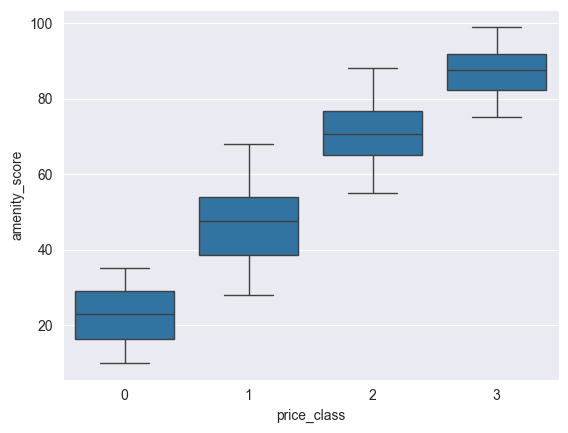

In [288]:
sns.boxplot(x="price_class", y="amenity_score", data=df)
plt.show()

In [289]:
# checking mean amenity_score (missing vs present) w.r.t number_of_reviews
amenity_score_missing = df["amenity_score"].isna().map({
    True: "amenity_score_missing",
    False: "amenity_score_present"
})
df.groupby(amenity_score_missing)["number_of_reviews"].mean()

amenity_score
amenity_score_missing    17.548035
amenity_score_present    23.129526
Name: number_of_reviews, dtype: float64

In [290]:
# checking mean amenity_score (missing vs present) w.r.t price_class
amenity_score_missing = df["amenity_score"].isna().map({
    True: "amenity_score_missing",
    False: "amenity_score_present"
})
df.groupby(amenity_score_missing)["price_class"].mean()

amenity_score
amenity_score_missing    1.085153
amenity_score_present    1.234938
Name: price_class, dtype: float64

#### Imputation strategy for `amenity_score`

The variable amenity_score shows a strong monotonic relationship with `price_class`, with mean values increasing consistently from lower to higher price categories. This indicates that the feature is highly informative for price prediction. Comparative analysis of listings with and without missing amenity scores showed minor differences in average `review counts` and `price class`, suggesting that missing values do not represent a fundamentally distinct subgroup. Given the predictive importance of the feature and the modest level of missing data, **global median** imputation was applied to preserve robustness against potential skew.

In [291]:
# filling in missing values with global median for `amenity_score`
df["amenity_score"] = df["amenity_score"].fillna(df["amenity_score"].median())

In [292]:
# e. neighbourhood_group
print(df["neighbourhood_group"].value_counts(dropna=False))
print(df["neighbourhood_group"].value_counts(normalize=True, dropna=False))
print("Missing:", df["neighbourhood_group"].isna().sum())

neighbourhood_group
Manhattan        17905
Brooklyn         16692
Queens            4696
Bronx              907
NaN                839
Staten Island      309
Name: count, dtype: int64
neighbourhood_group
Manhattan        0.433032
Brooklyn         0.403695
Queens           0.113573
Bronx            0.021936
NaN              0.020291
Staten Island    0.007473
Name: proportion, dtype: float64
Missing: 839


In [293]:
# relationship with target
df.groupby("neighbourhood_group")["price_class"].mean()

neighbourhood_group
Bronx            0.749724
Brooklyn         1.066379
Manhattan        1.509132
Queens           0.875000
Staten Island    0.857605
Name: price_class, dtype: float64

<Axes: xlabel='neighbourhood_group', ylabel='count'>

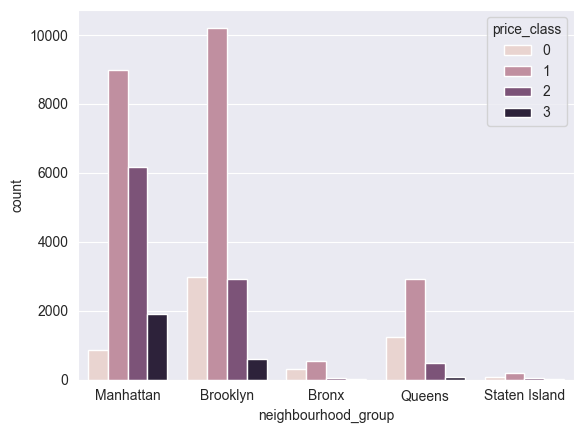

In [294]:
sns.countplot(x="neighbourhood_group", hue="price_class", data=df)

In [295]:
# checking if missing rows behave differently w.r.t price class
neighbourhood_missing = df["neighbourhood_group"].isna().map({
    True: "neighbourhood_missing",
    False: "neighbourhood_present"
})
df.groupby(neighbourhood_missing)["price_class"].mean()


neighbourhood_group
neighbourhood_missing    1.251490
neighbourhood_present    1.231208
Name: price_class, dtype: float64

In [296]:
# checking if missing rows behave differently w.r.t amenity_socre
neighbourhood_missing = df["neighbourhood_group"].isna().map({
    True: "neighbourhood_missing",
    False: "neighbourhood_present"
})
df.groupby(neighbourhood_missing)["amenity_score"].mean()

neighbourhood_group
neighbourhood_missing    52.624672
neighbourhood_present    51.960752
Name: amenity_score, dtype: float64

#### Imputation strategy for `neighbourhood_group`

The variable neighbourhood_group represents the borough location of each listing and exhibits a clear relationship with price class. Listings in Manhattan show the highest average price class, while Bronx listings show the lowest, confirming the feature’s structural importance.

The dataset contains 839 missing values (~2%). Comparative analysis revealed negligible differences in average price class and amenity score between listings with and without missing borough information, suggesting that missingness does not represent a distinct subgroup.

Since borough is a categorical geographic identifier, imputing missing values with the most frequent category would introduce artificial spatial bias. Therefore, missing values were replaced with a new category labeled **"Unknown"** to preserve categorical integrity without distorting the original distribution.

In [298]:
# filling with the unknown in the neighbourhood_grou[
df["neighbourhood_group"] = df["neighbourhood_group"].fillna("Unknown")

In [299]:
# f. room_type
print(df["room_type"].value_counts(dropna=False))
print(df["room_type"].value_counts(normalize=True, dropna=False))
print("Missing:", df["room_type"].isna().sum())

room_type
Entire home/apt    21099
Private room       18663
Shared room          975
NaN                  611
Name: count, dtype: int64
room_type
Entire home/apt    0.510279
Private room       0.451364
Shared room        0.023580
NaN                0.014777
Name: proportion, dtype: float64
Missing: 611


In [300]:
# checking relationship with the price_class
df.groupby("room_type")["price_class"].mean()

room_type
Entire home/apt    1.631594
Private room       0.817821
Shared room        0.506667
Name: price_class, dtype: float64

<Axes: xlabel='room_type', ylabel='count'>

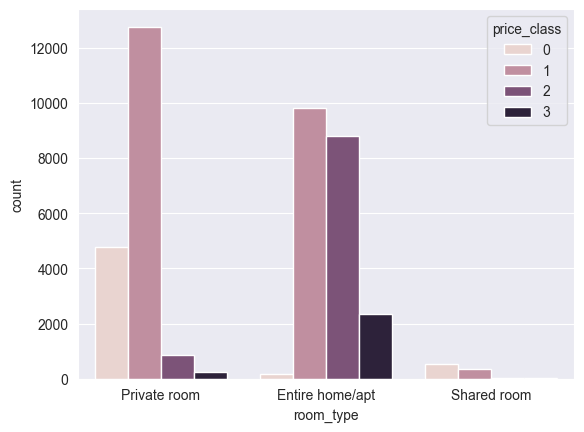

In [301]:
sns.countplot(x="room_type", hue="price_class", data=df)

In [302]:
# checking if the unknown rows behave differently
room_type_missing = df["room_type"].isna().map({
    True: "room_type_missing",
    False: "room_type_present"
})
df.groupby(room_type_missing)["amenity_score"].mean()

room_type
room_type_missing    52.076759
room_type_present    51.972686
Name: amenity_score, dtype: float64

In [303]:
# checking if the unknown rows behave differently
room_type_missing = df["room_type"].isna().map({
    True: "room_type_missing",
    False: "room_type_present"
})
df.groupby(room_type_missing)["price_class"].mean()

room_type
room_type_missing    1.216039
room_type_present    1.231853
Name: price_class, dtype: float64

#### Imputation strategy for `room_type`

The variable `room_type` contains 611 missing values (~1.5%). Comparative analysis shows negligible differences in mean `price_class` and `amenity_score` between missing and non-missing groups, indicating no strong structural bias. Rather than imputing with the modal category (which would distort class proportions), missing values were treated as a **separate category (“Unknown”)** prior to one-hot encoding. This approach preserves information while avoiding artificial bias.

In [304]:
# filling in the unknown type for `room_type`
df["room_type"] = df["room_type"].fillna("Unknown")

In [305]:
print("\n===== Missing Values after handling them =====")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)


===== Missing Values after handling them =====
neighbourhood_group    0
room_type              0
minimum_nights         0
amenity_score          0
number_of_reviews      0
availability_365       0
price_class            0
dtype: int64


### 3. Class Distribution of the Target Variable.

In [306]:
print("\n===== Class Distribution of Target Variable =====")
class_counts = df[TARGET].value_counts().sort_index(ascending=True)
class_percentage = (class_counts/df.shape[0])*100
class_distribution = pd.DataFrame({
    "counts": class_counts,
    "percentage": class_percentage.round(2)
})
print(class_distribution.to_markdown())



===== Class Distribution of Target Variable =====
|   price_class |   counts |   percentage |
|--------------:|---------:|-------------:|
|             0 |     5567 |        13.46 |
|             1 |    23287 |        56.32 |
|             2 |     9844 |        23.81 |
|             3 |     2650 |         6.41 |


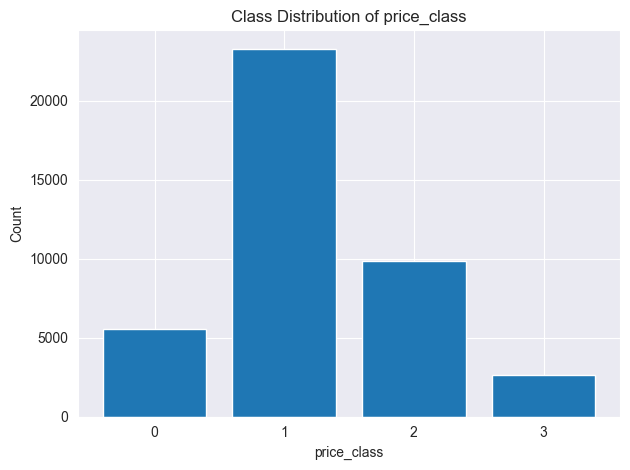

In [307]:
bars = plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title(f"Class Distribution of {TARGET}")
plt.xlabel("price_class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The target variable exhibits moderate to severe class imbalance. Class 1 dominates the dataset (56.32%), while Class 3 represents only 6.41% of samples. That means if your FFNN blindly predicts Class 1 for everything, it already achieves 56% accuracy. That’s a dangerously misleading baseline. This imbalance may bias a FFNN towards predicting the majority class, resulting in inflated overall accuracy but poor performance on minority classes.


### 4. Relationships between Individual Features and the Target Variable

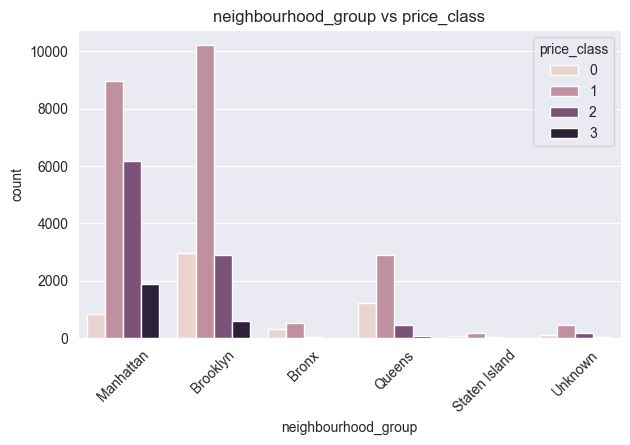

In [308]:
# relationship between neighbourhood_group and price_class
plt.figure(figsize=(7,4))
sns.countplot(x="neighbourhood_group", hue="price_class", data=df)
plt.xticks(rotation=45)
plt.title("neighbourhood_group vs price_class")
plt.show()

A countplot was used to examine the distribution of price_class across different neighbourhood_group categories.

The visualization shows a clear association between location and price category:

- Manhattan contains a noticeably higher proportion of listings in the upper price classes (2 and 3).

- Brooklyn is concentrated mainly in mid-level price classes (1 and 2), with fewer premium listings compared to Manhattan.

- Queens, Bronx, and Staten Island are dominated by lower price classes (0 and 1), with very limited representation in higher classes.

This pattern is economically intuitive. Property prices in real estate markets are strongly driven by geographic location, and premium central areas (e.g., Manhattan) command higher prices.

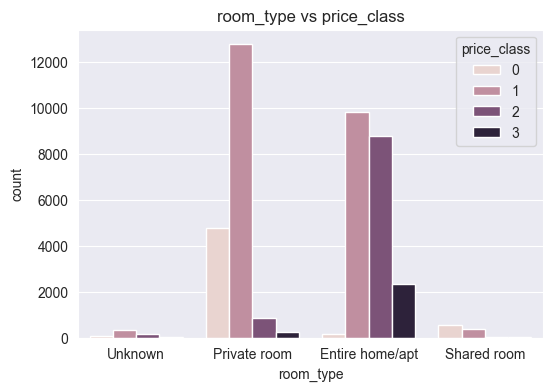

In [310]:
# relationship between room_type and price_class
plt.figure(figsize=(6,4))
sns.countplot(x="room_type", hue="price_class", data=df)
plt.title("room_type vs price_class")
plt.show()


The countplot shows a clear stratification of `price_class` across `room_type`. Entire homes are disproportionately represented in higher price tiers, while shared rooms are concentrated in lower tiers. Private rooms occupy an intermediate position. This indicates that `room_type` is a strong categorical predictor of `price_class`.

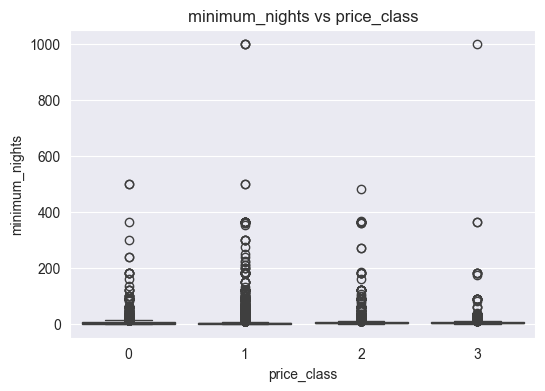

In [311]:
# relationship between minimum_nights and price_class
plt.figure(figsize=(6,4))
sns.boxplot(x="price_class", y="minimum_nights", data=df)
plt.title("minimum_nights vs price_class")
plt.show()

The boxplot of `minimum_nights` across price classes shows substantial overlap between categories, with no clear monotonic pattern. The distribution is heavily right-skewed and dominated by extreme outliers. The correlation with `price_class` is near zero (r ≈ 0.02), indicating minimal predictive value.

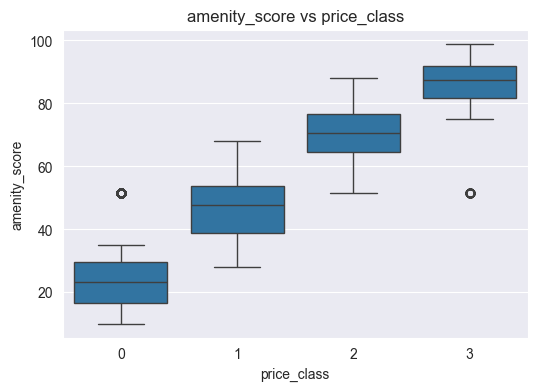

In [312]:
# relationship between amenity_score and price_class
plt.figure(figsize=(6,4))
sns.boxplot(x="price_class", y="amenity_score", data=df)
plt.title("amenity_score vs price_class")
plt.show()

The boxplot of `amenity_score` across price classes shows a clear monotonic increase, with minimal overlap between categories. The correlation coefficient between `amenity_score` and `price_class` is 0.87, indicating a very strong positive relationship. This suggests that `amenity_score` is the most influential numerical predictor in the dataset. No other numerical feature exhibits comparable predictive strength.

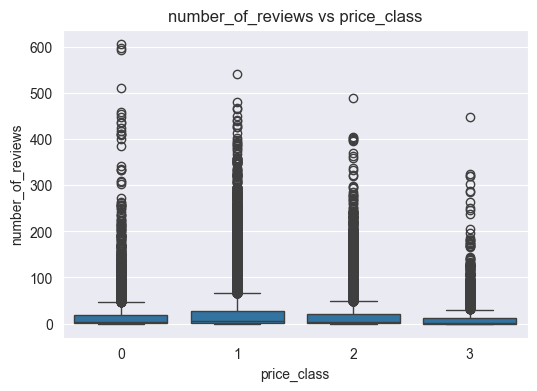

In [313]:
# relationship between number_of_reviews and price_class

plt.figure(figsize=(6,4))
sns.boxplot(x="price_class", y="number_of_reviews", data=df)
plt.title("number_of_reviews vs price_class")
plt.show()

The boxplot of `number_of_reviews` across price classes reveals substantial overlap in distributions. Median review counts are similar across categories, and the feature exhibits strong right skew with numerous outliers. The near-zero correlation (r ≈ −0.03) further confirms that review count has limited linear association with price_class. Therefore, `number_of_reviews` is not expected to be a dominant standalone predictor.

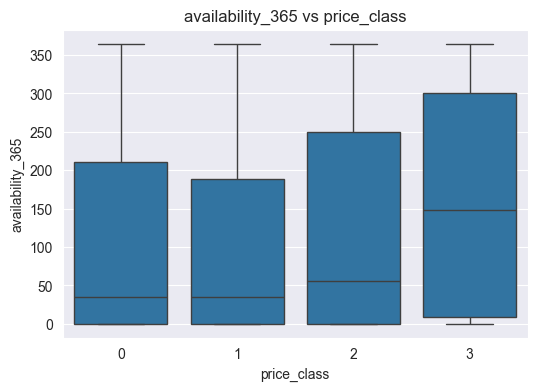

In [314]:
# relationship between availability_365 and price_class
plt.figure(figsize=(6,4))
sns.boxplot(x="price_class", y="availability_365", data=df)
plt.title("availability_365 vs price_class")
plt.show()

The boxplot of `availability_365` across price classes reveals a moderate upward shift in median availability for higher pricing tiers. Luxury listings (class 3) exhibit substantially higher median availability compared to lower-priced listings. However, considerable overlap exists across categories, and the correlation with the target remains weak (r ≈ 0.09). Therefore, `availability_365` provides moderate but not dominant predictive signal.

### 5. Correlation Matrix among Numerical Columns

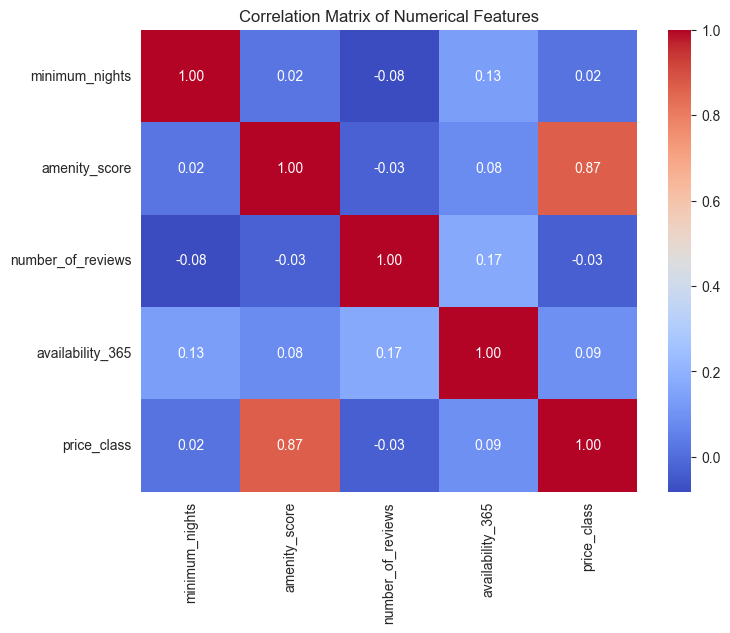

In [315]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

A correlation matrix was computed to examine relationships among numerical variables. The results show that correlations among predictor variables are weak (|r| < 0.2), indicating low multicollinearity and minimal redundancy between features. Therefore, no numerical features were removed based on correlation.

However, a strong positive correlation (r = 0.87) was observed between amenity_score and price_class. This suggests that amenity quality is strongly associated with pricing category and is likely to be a highly influential predictor in the feed-forward neural network model.
Based on this matrix:

`amenity_score` will likely dominate feature importance. Other numerical variables contribute weak linear signal. All the other features are not correlated strongly which means that
- No strong multicollinearity
- No redundant numerical features

Based on the above analysis,

**Most influential features:**

- `amenity_score` (strong monotonic increase + r = 0.87)

- `room_type` (clear categorical separation)

- `neighbourhood_group` (geographic pricing structure)

**Moderate influence:**

- `availability_365`

**Low influence:**

- `minimum_nights`

- `number_of_reviews`

**Suspiciously dominant Feature**

`amenity_score` shows correlation of 0.87 with target. That is unusually strong for real-world tabular data.Resultantly, it will likely dominate model learning. FFNN might rely heavily on this single feature.

### 6. Encoding Categorical Variables

In [316]:
# 4. Encoding Categorical Variables
print("\n===== Categorical Variable Summary =====\n")
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Number of categorical columns: {len(categorical_columns)}\n")
for idx,col in enumerate(categorical_columns):
    unique_values = df[col].dropna().unique()
    n_unique = len(unique_values)
    n_missing = df[col].isna().sum()
    print(f"{idx+1}. {col}")
    print(f"Number of unique categories: {n_unique}")
    # print(f"Missing values: {n_missing}")
    print("Categories:")

    for val in sorted(unique_values):
        print(f"  - {val}")
    print("\n")
print(f"Before encoding\n {df.head()}")
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)
print(f"After encoding\n {df.head()}")


===== Categorical Variable Summary =====

Number of categorical columns: 2

1. neighbourhood_group
Number of unique categories: 6
Categories:
  - Bronx
  - Brooklyn
  - Manhattan
  - Queens
  - Staten Island
  - Unknown


2. room_type
Number of unique categories: 4
Categories:
  - Entire home/apt
  - Private room
  - Shared room
  - Unknown


Before encoding
   neighbourhood_group        room_type  minimum_nights  amenity_score  \
0           Manhattan          Unknown             2.0           82.5   
1           Manhattan     Private room             2.0           53.7   
2            Brooklyn     Private room             2.0           47.8   
3           Manhattan  Entire home/apt             2.0           58.8   
4               Bronx     Private room             2.0           32.2   

   number_of_reviews  availability_365  price_class  
0               15.0             254.0            3  
1                1.0               0.0            1  
2               70.0              90

The categorical variables `neighbourhood_group` and `room_type` were encoded using **One-Hot Encoding**. This method is appropriate because both variables are nominal and do not possess an inherent ordering. Label encoding would introduce artificial ordinal relationships, potentially misleading the neural network. Given the relatively small number of categories, the dimensionality increase from one-hot encoding is minimal and does not pose a risk of high sparsity.

### Normalizing Numerical Features


In [317]:
print(f"Numerical columns")

numerical_cols = df.drop("price_class", axis=1) \
                   .select_dtypes(include=['int64','float64']) \
                   .columns.tolist()
print("\nBefore normalizing:")
print(df.head())
# normalizing
df[numerical_cols] = (
    df[numerical_cols] - df[numerical_cols].mean()
) / df[numerical_cols].std()
print("\nAfter normalizing:")
print(df.head())

Numerical columns

Before normalizing:
   minimum_nights  amenity_score  number_of_reviews  availability_365  \
0             2.0           82.5               15.0             254.0   
1             2.0           53.7                1.0               0.0   
2             2.0           47.8               70.0              90.0   
3             2.0           58.8                1.0              44.0   
4             2.0           32.2                0.0              89.0   

   price_class  neighbourhood_group_Brooklyn  neighbourhood_group_Manhattan  \
0            3                         False                           True   
1            1                         False                           True   
2            1                          True                          False   
3            1                         False                           True   
4            1                         False                          False   

   neighbourhood_group_Queens  neighbourhood_gr

All numerical features were normalized using Z-score standardization. For each feature, the mean was subtracted and the result divided by the standard deviation:

$z = \frac{x - \mu}{\sigma}$

This transformation centers each feature around zero with unit variance.

Normalization was performed on the training set only, and the same transformation parameters were later applied to validation/test data to prevent data leakage.

Z-score standardization was selected because feed-forward neural networks are sensitive to feature scale. Standardizing the inputs ensures that all numerical features contribute proportionally during gradient-based optimization, improves convergence stability, and prevents features with larger magnitudes from dominating the learning process.